# Coral Bleaching — Predictive Model

Two-stage approach:
- **Stage 1 — Classifier:** predict whether bleaching occurs (binary: 0 / >0)
- **Stage 2 — Regressor:** predict severity (%) given that bleaching is detected

This handles the 39.5% zero-inflation in the target and improves overall performance.

Both models are serialized and used live in the Streamlit dashboard.

## 1. Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score
)
from xgboost import XGBClassifier, XGBRegressor
import shap

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120
SEED = 42

## 2. Load & feature engineering

In [4]:
df = pd.read_csv('../data/coral_clean.csv', parse_dates=['date'])
print(f'Shape: {df.shape}')
df.head(3)

Shape: (23203, 25)


,date,year,latitude,longitude,ocean,realm,ecoregion,distance_to_shore,exposure,depth_m,...,sst,sst_maximum,ssta,ssta_maximum,ssta_frequency,tsa,tsa_maximum,tsa_frequency,ssta_dhw,tsa_dhw
0,2005-09-15,2005,23.163,-82.5260,Atlantic,Tropical Atlantic,Cuba and Cayman Islands,8519.23,Exposed,10.0,...,28.90,31.54,-0.46,2.24,0.0,-0.80,1.83,0.00,0.00,0.00
1,1991-03-15,1991,-17.575,-149.7833,Pacific,Eastern Indo-Pacific,Society Islands French Polynesia,1431.62,Exposed,14.0,...,30.15,31.86,1.29,3.10,0.5,1.29,3.00,0.25,0.26,0.26
2,2006-01-15,2006,18.369,-64.5640,Atlantic,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,182.33,Exposed,7.0,...,26.03,30.99,0.04,2.83,16.0,-2.64,2.31,7.00,0.00,0.00


### Feature selection rationale

| Feature | Type | Reason to include |
|---|---|---|
| `ssta_dhw` | numeric | Best predictor (r=0.28); DHW ≥ 4 triggers bleaching |
| `ssta_frequency` | numeric | Chronic vs acute stress frequency |
| `ssta` | numeric | Instantaneous temp anomaly |
| `sst` | numeric | Absolute temperature (°C) |
| `depth_m` | numeric | Proxy for light + water movement |
| `bleaching_level` | categorical | Colony vs Population — huge confounder |
| `exposure` | categorical | Exposed/Sheltered/Sometimes |
| `ocean` | categorical | Geographic baseline differences |

**Excluded (collinear):** `tsa_dhw` (r=0.85 with `ssta_dhw`), `tsa`/`tsa_frequency` (r>0.7 with ssta equivalents), `sst_maximum`, `ssta_maximum`

**Excluded (near-zero correlation):** `turbidity`, `cyclone_frequency`, `windspeed`, `distance_to_shore`

In [5]:
FEATURES = [
    'ssta_dhw', 'ssta_frequency', 'ssta', 'sst', 'depth_m',  # numeric
    'bleaching_level', 'exposure', 'ocean'                    # categorical
]
NUM_FEATS = ['ssta_dhw', 'ssta_frequency', 'ssta', 'sst', 'depth_m']
CAT_FEATS = ['bleaching_level', 'exposure', 'ocean']

X = df[FEATURES].copy()
y = df['percent_bleaching'].copy()

# Stage 1 target: binary
y_cls = (y > 0).astype(int)

# Stage 2 target: severity among bleached, log1p-transformed
mask_pos = y > 0
X_pos = X[mask_pos]
y_reg = np.log1p(y[mask_pos])

print(f'Full dataset:        {X.shape[0]:,} rows')
print(f'Stage 1 — bleached:  {y_cls.sum():,} ({y_cls.mean():.1%})')
print(f'Stage 2 — positive:  {mask_pos.sum():,} rows for regression')
print(f'log1p target skew:   {y_reg.skew():.3f} (target < 0.5)')

Full dataset:        23,203 rows
Stage 1 — bleached:  14,036 (60.5%)
Stage 2 — positive:  14,036 rows for regression
log1p target skew:   0.075 (target < 0.5)


## 3. Preprocessing pipeline

In [6]:
# Ordinal encoder for categorical features (XGBoost handles ordinal natively)
# StandardScaler for numerics (not required for XGBoost, but helps SHAP interpretation)
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), NUM_FEATS),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), CAT_FEATS)
], remainder='drop')

# Feature names after transform (for SHAP plots)
FEAT_NAMES = NUM_FEATS + CAT_FEATS
print('Feature order after transform:', FEAT_NAMES)

Feature order after transform: ['ssta_dhw', 'ssta_frequency', 'ssta', 'sst', 'depth_m', 'bleaching_level', 'exposure', 'ocean']


## 4. Train / test split

⚠️ **Temporal split** — using year < 2016 for training and 2016+ for test.
This is more realistic than random split: the model is trained on the past and evaluated on future data.
It also avoids leaking information from the same bleaching event into both sets.

In [7]:
# Temporal split: train on <2016, test on 2016+
train_mask = df['year'] < 2016
test_mask  = df['year'] >= 2016

# ── Stage 1 splits ──
X_train_cls = X[train_mask];  y_train_cls = y_cls[train_mask]
X_test_cls  = X[test_mask];   y_test_cls  = y_cls[test_mask]

# ── Stage 2 splits (positive only, from train/test subsets) ──
pos_train = mask_pos & train_mask
pos_test  = mask_pos & test_mask
X_train_reg = X[pos_train];  y_train_reg = np.log1p(y[pos_train])
X_test_reg  = X[pos_test];   y_test_reg  = np.log1p(y[pos_test])

print(f'Train: {train_mask.sum():,} rows ({df.loc[train_mask,"year"].min()}–{df.loc[train_mask,"year"].max()})')
print(f'Test:  {test_mask.sum():,} rows  ({df.loc[test_mask,"year"].min()}–{df.loc[test_mask,"year"].max()})')
print(f'  Stage 1 train positives: {y_train_cls.sum():,} ({y_train_cls.mean():.1%})')
print(f'  Stage 1 test  positives: {y_test_cls.sum():,} ({y_test_cls.mean():.1%})')
print(f'  Stage 2 train rows: {X_train_reg.shape[0]:,}')
print(f'  Stage 2 test  rows: {X_test_reg.shape[0]:,}')

Train: 19,977 rows (1980–2015)
Test:  3,226 rows  (2016–2020)
  Stage 1 train positives: 12,598 (63.1%)
  Stage 1 test  positives: 1,438 (44.6%)
  Stage 2 train rows: 12,598
  Stage 2 test  rows: 1,438


## 5. Stage 1 — Bleaching classifier

XGBoost binary classifier. `scale_pos_weight` adjusts for class imbalance.

In [8]:
neg, pos = (y_train_cls == 0).sum(), (y_train_cls == 1).sum()
scale_pw  = neg / pos  # compensate for imbalance
print(f'scale_pos_weight = {scale_pw:.2f}')

clf_pipeline = Pipeline([
    ('pre', preprocessor),
    ('clf', XGBClassifier(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pw,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=SEED,
        n_jobs=-1
    ))
])

clf_pipeline.fit(X_train_cls, y_train_cls)
print('Classifier trained.')

scale_pos_weight = 0.59
Classifier trained.


=== STAGE 1 — TEST SET ===
              precision    recall  f1-score   support

No bleaching       0.66      0.96      0.78      1788
    Bleached       0.89      0.38      0.53      1438

    accuracy                           0.70      3226
   macro avg       0.77      0.67      0.66      3226
weighted avg       0.76      0.70      0.67      3226

ROC-AUC: 0.7215


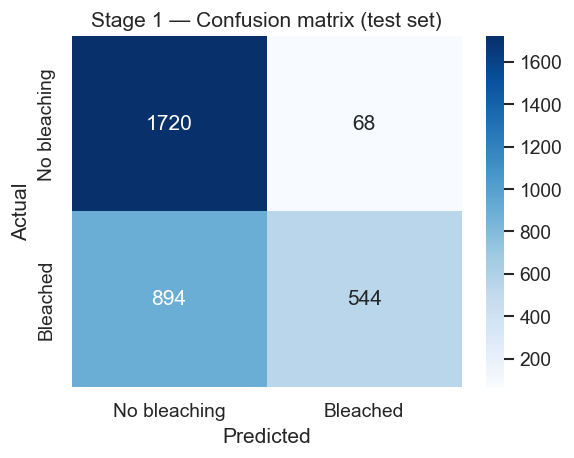

In [9]:
# ── Evaluation ────────────────────────────────────────────────────────────
y_pred_cls   = clf_pipeline.predict(X_test_cls)
y_proba_cls  = clf_pipeline.predict_proba(X_test_cls)[:, 1]

print('=== STAGE 1 — TEST SET ===')
print(classification_report(y_test_cls, y_pred_cls, target_names=['No bleaching','Bleached']))
print(f'ROC-AUC: {roc_auc_score(y_test_cls, y_proba_cls):.4f}')

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test_cls, y_pred_cls)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No bleaching','Bleached'],
            yticklabels=['No bleaching','Bleached'])
ax.set_title('Stage 1 — Confusion matrix (test set)')
ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

## 6. Stage 2 — Severity regressor

XGBoost regressor trained only on records where bleaching > 0.
Target is `log1p(percent_bleaching)` — nearly symmetric after transform (skew ≈ 0.07).
Predictions are back-transformed with `expm1()` for interpretability.

In [10]:
reg_pipeline = Pipeline([
    ('pre', preprocessor),
    ('reg', XGBRegressor(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        random_state=SEED,
        n_jobs=-1
    ))
])

reg_pipeline.fit(X_train_reg, y_train_reg)
print('Regressor trained.')

Regressor trained.


=== STAGE 2 — TEST SET (back-transformed to %) ===
MAE:  14.01%
RMSE: 23.53%
R²:   0.2224


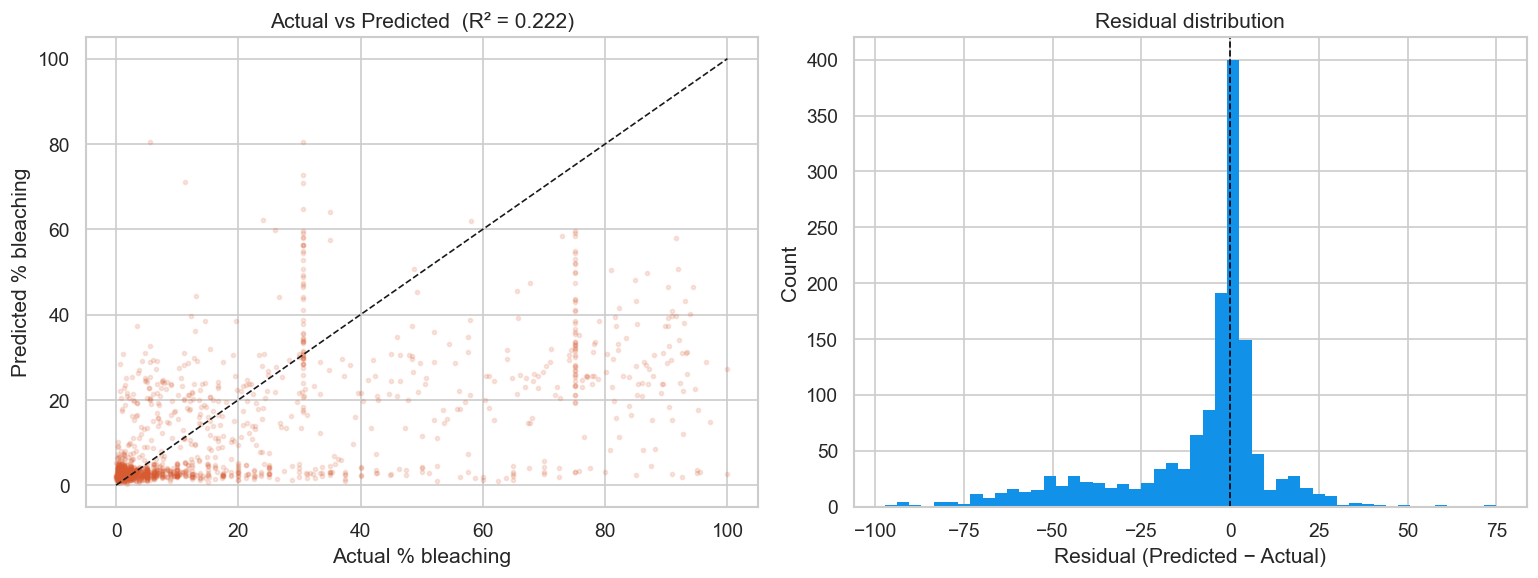

In [11]:
# ── Evaluation ────────────────────────────────────────────────────────────
y_pred_log = reg_pipeline.predict(X_test_reg)
y_pred_reg = np.expm1(y_pred_log).clip(0, 100)   # back to % scale
y_true_reg = np.expm1(y_test_reg)                 # back to % scale

mae  = mean_absolute_error(y_true_reg, y_pred_reg)
rmse = mean_squared_error(y_true_reg, y_pred_reg)**0.5
r2   = r2_score(y_true_reg, y_pred_reg)

print('=== STAGE 2 — TEST SET (back-transformed to %) ===')
print(f'MAE:  {mae:.2f}%')
print(f'RMSE: {rmse:.2f}%')
print(f'R²:   {r2:.4f}')

# Actual vs predicted
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_true_reg, y_pred_reg, alpha=0.15, s=6, color='#D85A30')
lim = max(y_true_reg.max(), y_pred_reg.max())
axes[0].plot([0, lim], [0, lim], 'k--', linewidth=1)
axes[0].set_xlabel('Actual % bleaching')
axes[0].set_ylabel('Predicted % bleaching')
axes[0].set_title(f'Actual vs Predicted  (R² = {r2:.3f})')

residuals = y_pred_reg - y_true_reg
axes[1].hist(residuals, bins=50, color='#1192e8', edgecolor='none')
axes[1].axvline(0, color='black', linewidth=1, linestyle='--')
axes[1].set_xlabel('Residual (Predicted − Actual)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual distribution')

plt.tight_layout()
plt.show()

## 7. End-to-end prediction function

Combines Stage 1 + Stage 2 into a single `predict()` call.
This is what the Streamlit dashboard uses directly.

In [12]:
def predict_bleaching(X_input: pd.DataFrame) -> dict:
    """
    Full two-stage prediction.
    Returns: {
        'bleached':    bool array  (Stage 1),
        'probability': float array (Stage 1 confidence),
        'severity':    float array (Stage 2, % bleaching; NaN if Stage 1 = 0)
        'final':       float array (0 if not bleached, severity otherwise)
    }
    """
    # Reset index so boolean masking works regardless of original DataFrame index
    X = X_input.reset_index(drop=True)

    proba    = clf_pipeline.predict_proba(X)[:, 1]
    bleached = (proba >= 0.5)

    severity = np.full(len(X), np.nan)
    if bleached.any():
        log_pred = reg_pipeline.predict(X[bleached])
        severity[bleached] = np.expm1(log_pred).clip(0, 100)

    final = np.where(bleached, severity, 0.0)

    return {
        'bleached':    bleached,
        'probability': proba,
        'severity':    severity,
        'final':       final
    }


# Quick sanity test
sample = X_test_cls.head(5).reset_index(drop=True)
y_sample = y[test_mask].head(5).reset_index(drop=True)

result = predict_bleaching(sample)
for i in range(5):
    print(f'Sample {i}: bleached={result["bleached"][i]}, '
          f'prob={result["probability"][i]:.2f}, '
          f'severity={result["final"][i]:.1f}%  '
          f'(actual: {y_sample[i]:.1f}%)')


Sample 0: bleached=True, prob=0.69, severity=19.2%  (actual: 75.0%)
Sample 1: bleached=True, prob=0.95, severity=35.4%  (actual: 75.0%)
Sample 2: bleached=True, prob=0.94, severity=59.7%  (actual: 75.0%)
Sample 3: bleached=True, prob=0.68, severity=25.4%  (actual: 75.0%)
Sample 4: bleached=True, prob=0.81, severity=30.1%  (actual: 75.0%)


## 8. SHAP feature importance

SHAP (SHapley Additive exPlanations) shows how much each feature contributes to each prediction.
This is the key to understanding *why* the model predicts high bleaching — the domain knowledge layer.

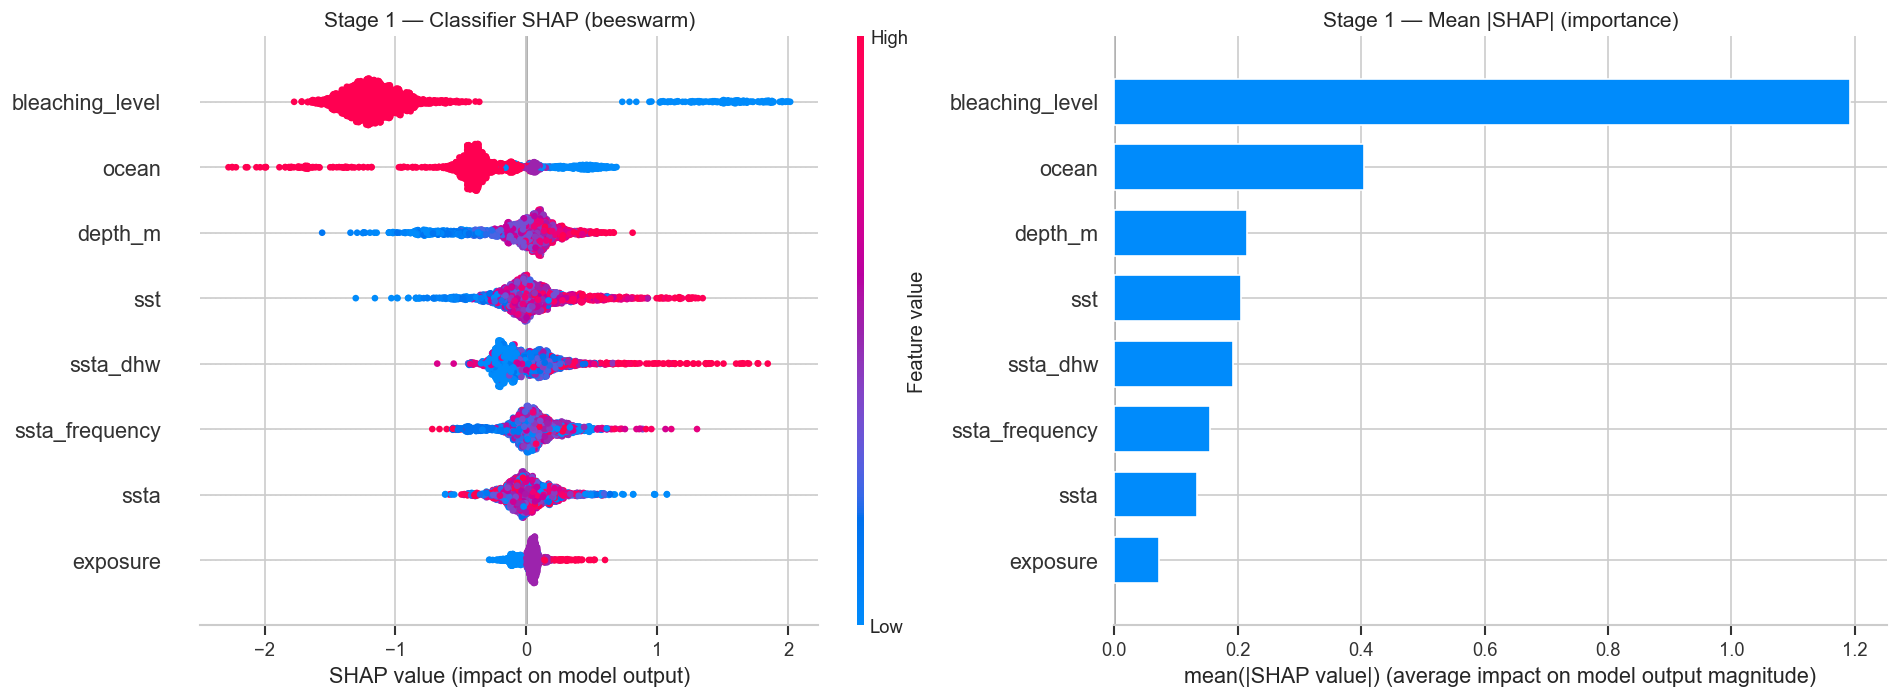

In [13]:
# ── Extract the trained XGB model from pipeline for SHAP ─────────────────
pre_fitted = clf_pipeline.named_steps['pre']
X_train_t  = pre_fitted.transform(X_train_cls)
X_test_t   = pre_fitted.transform(X_test_cls)

explainer_cls = shap.TreeExplainer(clf_pipeline.named_steps['clf'])
shap_vals_cls = explainer_cls.shap_values(X_test_t[:2000])  # sample for speed

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plt.sca(axes[0])
shap.summary_plot(shap_vals_cls, X_test_t[:2000],
                  feature_names=FEAT_NAMES, show=False, plot_size=None)
axes[0].set_title('Stage 1 — Classifier SHAP (beeswarm)')

plt.sca(axes[1])
shap.summary_plot(shap_vals_cls, X_test_t[:2000],
                  feature_names=FEAT_NAMES, plot_type='bar', show=False, plot_size=None)
axes[1].set_title('Stage 1 — Mean |SHAP| (importance)')

plt.tight_layout()
plt.show()

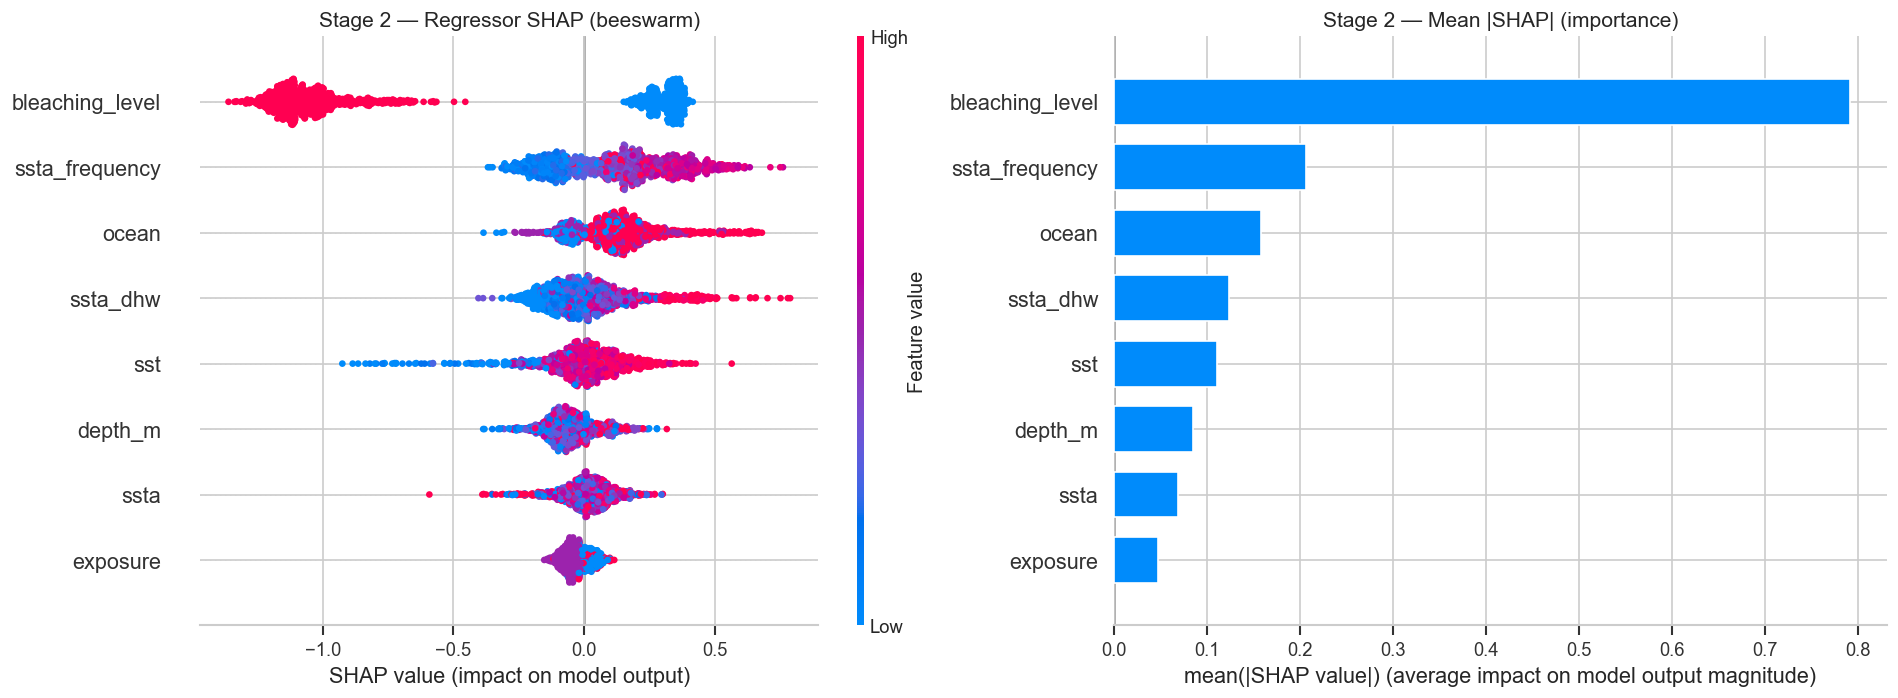

In [14]:
# ── SHAP for Stage 2 (regressor) ─────────────────────────────────────────
pre_reg_fitted = reg_pipeline.named_steps['pre']
X_test_reg_t   = pre_reg_fitted.transform(X_test_reg)

explainer_reg  = shap.TreeExplainer(reg_pipeline.named_steps['reg'])
shap_vals_reg  = explainer_reg.shap_values(X_test_reg_t[:2000])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plt.sca(axes[0])
shap.summary_plot(shap_vals_reg, X_test_reg_t[:2000],
                  feature_names=FEAT_NAMES, show=False, plot_size=None)
axes[0].set_title('Stage 2 — Regressor SHAP (beeswarm)')

plt.sca(axes[1])
shap.summary_plot(shap_vals_reg, X_test_reg_t[:2000],
                  feature_names=FEAT_NAMES, plot_type='bar', show=False, plot_size=None)
axes[1].set_title('Stage 2 — Mean |SHAP| (importance)')

plt.tight_layout()
plt.show()

## 9. Historical scenario presets

These are real-world input combinations used as presets in the dashboard.
The user can click a scenario to auto-fill the sliders and see the model's prediction.

In [15]:
PRESETS = {
    'El Niño 1998 (Indian Ocean)': {
        'ssta_dhw': 8.5, 'ssta_frequency': 6.0, 'ssta': 2.1,
        'sst': 30.2, 'depth_m': 5.0,
        'bleaching_level': 'Colony', 'exposure': 'Exposed', 'ocean': 'Indian'
    },
    'El Niño 2016 (Great Barrier Reef)': {
        'ssta_dhw': 7.2, 'ssta_frequency': 5.5, 'ssta': 1.8,
        'sst': 29.5, 'depth_m': 5.0,
        'bleaching_level': 'Colony', 'exposure': 'Exposed', 'ocean': 'Pacific'
    },
    'Healthy reef': {
        'ssta_dhw': 0.0, 'ssta_frequency': 0.0, 'ssta': -0.3,
        'sst': 26.5, 'depth_m': 8.0,
        'bleaching_level': 'Population', 'exposure': 'Sheltered', 'ocean': 'Pacific'
    },
    'Red Sea (resilient)': {
        'ssta_dhw': 2.0, 'ssta_frequency': 1.5, 'ssta': 0.5,
        'sst': 28.0, 'depth_m': 10.0,
        'bleaching_level': 'Population', 'exposure': 'Sheltered', 'ocean': 'Red Sea'
    },
    'Caribbean 2005 event': {
        'ssta_dhw': 6.0, 'ssta_frequency': 4.0, 'ssta': 1.2,
        'sst': 29.3, 'depth_m': 10.0,
        'bleaching_level': 'Colony', 'exposure': 'Exposed', 'ocean': 'Atlantic'
    }
}

print('=== PRESET PREDICTIONS ===')
for name, vals in PRESETS.items():
    X_preset = pd.DataFrame([vals])[FEATURES]
    res = predict_bleaching(X_preset)
    print(f'{name:<40} → {res["final"][0]:.1f}%  (prob={res["probability"][0]:.2f})')

=== PRESET PREDICTIONS ===
El Niño 1998 (Indian Ocean)              → 13.0%  (prob=0.90)
El Niño 2016 (Great Barrier Reef)        → 13.9%  (prob=0.79)
Healthy reef                             → 0.0%  (prob=0.18)
Red Sea (resilient)                      → 0.0%  (prob=0.07)
Caribbean 2005 event                     → 9.4%  (prob=0.89)


## 10. Save models for dashboard

Both pipelines (preprocessor included) are serialized with `joblib`.
The dashboard loads them at startup — no retraining needed.

In [16]:
import os
os.makedirs('models', exist_ok=True)

joblib.dump(clf_pipeline, 'models/clf_pipeline.joblib')
joblib.dump(reg_pipeline, 'models/reg_pipeline.joblib')
joblib.dump(PRESETS,      'models/presets.joblib')
joblib.dump(FEAT_NAMES,   'models/feature_names.joblib')

# Also save SHAP explainers so dashboard doesn't need to re-fit
joblib.dump(explainer_cls, 'models/explainer_clf.joblib')
joblib.dump(explainer_reg, 'models/explainer_reg.joblib')

print('Saved:')
for f in os.listdir('models'):
    size = os.path.getsize(f'models/{f}') / 1024
    print(f'  models/{f}  ({size:.0f} KB)')

Saved:
  models/reg_pipeline.joblib  (1037 KB)
  models/explainer_clf.joblib  (2967 KB)
  models/explainer_reg.joblib  (3116 KB)
  models/presets.joblib  (1 KB)
  models/clf_pipeline.joblib  (964 KB)
  models/feature_names.joblib  (0 KB)


## ✅ Model summary

| | Stage 1 (classifier) | Stage 2 (regressor) |
|---|---|---|
| Task | Is bleaching > 0? | How severe is it? |
| Model | XGBoost (binary) | XGBoost (regression) |
| Target | Binary 0/1 | log1p(% bleaching) |
| Train set | year < 2016 | year < 2016, positive only |
| Eval metric | ROC-AUC, F1 | MAE, RMSE, R² |

Next step: **`streamlit_app.py`** — loads these models and serves the interactive dashboard.

Key dashboard features:
- Interactive world map (pydeck) colored by % bleaching
- Temporal trend chart with El Niño annotations
- Live predictor with sliders + SHAP waterfall
- Historical presets (El Niño 1998, 2016 GBR, Healthy reef, etc.)